 ** Sommaire **
 - <a href="#C1">1 - Régression Logistique</a>
     - <a href="#C2">    1.1 - Évaluation du Modèle</a>
     - <a href="#C3">    1.2 - FastText</a>
     - <a href="#C4">    1.2 - GloVe</a>
 - <a href="#C5">2 - Modèle LSTM </a>
     - <a href="#C6">    2.1 - Évaluation du Modèle</a>
     - <a href="#C7">    2.2 - FastText</a>
     - <a href="#C8">    2.3 - GloVe</a>
 - <a href="#C9">3 - Modèle BERT </a>
     - <a href="#C10">   3.1 - Évaluation du Modèle </a>

In [2]:
#Importer les librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import os

# Spécifiez le nouveau répertoire
new_directory = "/Users/aesseddiki"
# Changer le répertoire courant
os.chdir(new_directory)

# Vérifiez le répertoire courant après le changement
print(os.getcwd())

C:\Users\aesseddiki


In [4]:
data_echant = pd.read_csv("data_echant.csv", encoding='latin-1') 
print(data_echant.shape)

(158146, 2)


In [5]:
# Supprimer les lignes contenant des valeurs NaN dans data_echant
data_echant = data_echant.dropna()

# Afficher les premières lignes pour vérifier le nettoyage
data_echant.head()

,Etiquette,Tweet_corrige
0,4,han open book ask anything want hit ask away g...
1,4,take care hope see soon maybe next time perform
2,0,apparently magically worked time oh server boo...
3,4,almost perfect weekend perfect people love forest
4,4,rally also school drink milk


In [6]:
# Compter le nombre de lignes manquantes dans la colonne 'Tweet_corrige'
missing_values_count = data_echant['Tweet_corrige'].isna().sum()

# Afficher le nombre de lignes manquantes
print(f"Nombre de lignes manquantes dans 'Tweet_corrige' : {missing_values_count}")


Nombre de lignes manquantes dans 'Tweet_corrige' : 0


In [7]:
# Remplacer les modalités 4 par 1 dans la colonne "Etiquette"
data_echant['Etiquette'] = data_echant['Etiquette'].replace({4: 1})

In [8]:
# Échantillonner équitablement 5000 tweets dans data_echant, avec 2500 pour chaque modalité
data = pd.concat([
    data_echant[data_echant['Etiquette'] == 0].sample(n=5000, random_state=42),
    data_echant[data_echant['Etiquette'] == 1].sample(n=5000, random_state=42)
])

# Afficher le résultat pour vérification
data.head()


,Etiquette,Tweet_corrige
44353,0,huh who going showcase sure come anyways trip ...
60769,0,grandpa hospital day suck get better
92787,0,know kept saying hour going corner sit traffic...
119851,0,sophomore g wan na go c f
86450,0,sad coz sad


In [9]:
data.shape

(10000, 2)

### <a name="C1">1 - Régression Logistique</a>

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [12]:
# Séparer les caractéristiques (X) et la variable cible (y)
X = data['Tweet_corrige']
y = data['Etiquette']

In [13]:
# Utiliser CountVectorizer pour transformer les tweets en vecteurs numériques
vectorizer = CountVectorizer()
X_vect = vectorizer.fit_transform(X)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X_vect, y, test_size=0.3, random_state=42)

In [15]:
# Créer l'instance du modèle
model = LogisticRegression()

# Entraîner le modèle sur les données d'entraînement
model.fit(X_train, y_train)


LogisticRegression()

In [16]:
# Prédire les valeurs sur les données de test
y_pred = model.predict(X_test)

#### <a name="C2">1.1 - Évaluation du Modèle</a>

In [18]:
# Calculer la matrice de confusion
conf_matrix = confusion_matrix(y_test, y_pred)

# Afficher la matrice de confusion
print("Matrice de confusion :\n", conf_matrix)

# Optionnel : Afficher le rapport de classification
print("\nRapport de classification :\n", classification_report(y_test, y_pred))


Matrice de confusion :
 [[1051  486]
 [ 371 1092]]

Rapport de classification :
               precision    recall  f1-score   support

           0       0.74      0.68      0.71      1537
           1       0.69      0.75      0.72      1463

    accuracy                           0.71      3000
   macro avg       0.72      0.72      0.71      3000
weighted avg       0.72      0.71      0.71      3000



In [19]:
conf_matrix_df = pd.DataFrame(conf_matrix, index=['Actual Negatif', 'Actual Positif'], columns=['Predicted Negatif', 'Predicted Positif'])
print("Matrice de confusion :\n", conf_matrix_df)

Matrice de confusion :
                 Predicted Negatif  Predicted Positif
Actual Negatif               1051                486
Actual Positif                371               1092


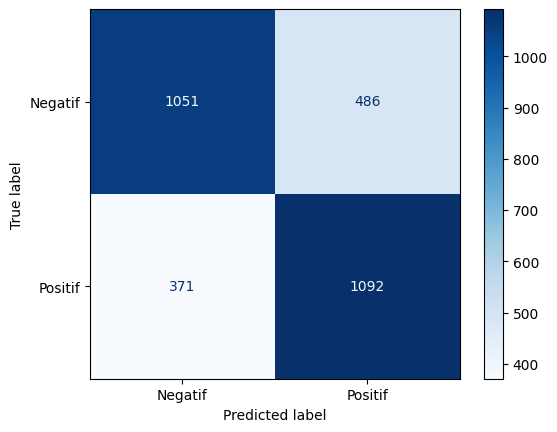

In [20]:
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Negatif', 'Positif'])
disp.plot(cmap=plt.cm.Blues)
plt.show()

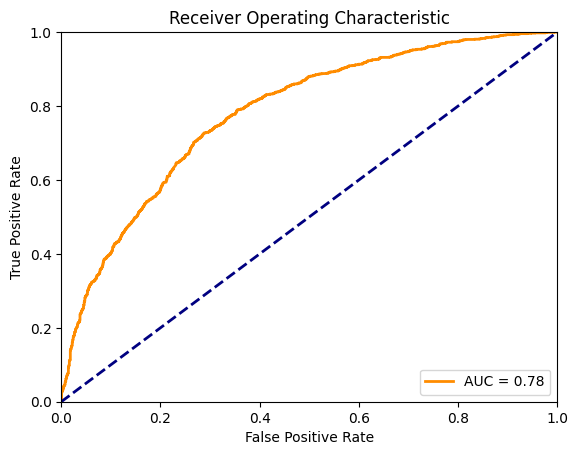

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Obtenir les probabilités de la classe positive sur les données de test
y_prob = model.predict_proba(X_test)[:, 1]  # Probabilités pour la classe positive

# Si 4 est supposé être l'étiquette positive, on peut convertir les valeurs
y_test_adjusted = y_test.replace(4, 1)

# Recalculer les probabilités et les courbes ROC avec y_test ajusté
fpr, tpr, _ = roc_curve(y_test_adjusted, y_prob)
roc_auc = auc(fpr, tpr)

# Affichage de la courbe ROC
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='AUC = %0.2f' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

#### <a name="C3">1.2 - FastText</a>

In [23]:
!pip install gensim

In [24]:
from gensim.models import FastText

# Charger les tweets 
with open("tweets.txt", "w", encoding="utf-8") as f:
    for tweet in data['Tweet_corrige'].dropna():
        f.write(tweet + "\n")

In [25]:

# Charger les données pour FastText via gensim
with open("tweets.txt", "r", encoding="utf-8") as f:
    sentences = [line.strip().split() for line in f]

Entraînez un modèle FastText pour créer des vecteurs de mots, et les utiliser pour transformer les tweets en vecteurs, puis appliquez une régression logistique pour prédire les étiquettes sur les données de test.

In [27]:
# Entraîner le modèle FastText avec gensim
model = FastText(sentences, vector_size=100, window=5, min_count=1, sg=1)

# Fonction pour obtenir les vecteurs FastText d'un texte
def get_fasttext_vector(text, model):
    tokens = text.split()
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros((100,))

# Appliquer la fonction pour obtenir les vecteurs FastText pour chaque tweet
X_vect = np.array([get_fasttext_vector(tweet, model) for tweet in data['Tweet_corrige'].dropna()])
y = data['Etiquette'].dropna().values

# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X_vect, y, test_size=0.3, random_state=42)

# Créer l'instance du modèle de régression logistique
model_logistic = LogisticRegression()
model_logistic.fit(X_train, y_train)

# Prédire les valeurs sur les données de test
y_pred = model_logistic.predict(X_test)

In [28]:
# Calculer et afficher la matrice de confusion
conf_matrix = confusion_matrix(y_test, y_pred)
conf_matrix_df = pd.DataFrame(conf_matrix, index=['Actual Negatif', 'Actual Positif'], columns=['Predicted Negatif', 'Predicted Positif'])
print("Matrice de confusion :\n", conf_matrix_df)

Matrice de confusion :
                 Predicted Negatif  Predicted Positif
Actual Negatif                655                882
Actual Positif                372               1091


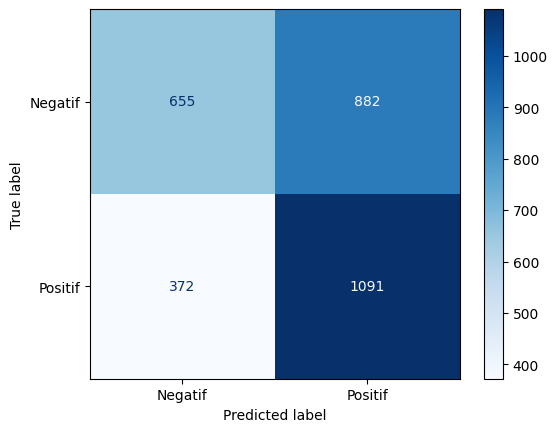

In [29]:
# Afficher la matrice de confusion sous forme de graphique
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Negatif', 'Positif'])
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [30]:
# Afficher le rapport de classification
print("\nRapport de classification :\n", classification_report(y_test, y_pred))


Rapport de classification :
               precision    recall  f1-score   support

           0       0.64      0.43      0.51      1537
           1       0.55      0.75      0.64      1463

    accuracy                           0.58      3000
   macro avg       0.60      0.59      0.57      3000
weighted avg       0.60      0.58      0.57      3000



#### <a name="C4">1.3 - Glove</a>

In [32]:
# Charger les vecteurs GloVe
def load_glove_embeddings(file_path):
    embeddings_index = {}
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs
    return embeddings_index

glove_file_path = '/Users/aesseddiki/glove.6B.100d.txt'  # Chemin complet vers le fichier
glove_embeddings = load_glove_embeddings(glove_file_path)

In [33]:
def get_average_glove_vector(tokens_list, embeddings, vector_size):
    # Génère un vecteur moyen pour chaque tweet
    return np.mean([embeddings.get(token, np.zeros(vector_size)) for token in tokens_list], axis=0)

# Exemple d'application : convertir chaque tweet en vecteur
data.loc[:, 'Tweet_corrige_tokenized'] = data['Tweet_corrige'].apply(lambda x: x.split())
X_glove = np.array([get_average_glove_vector(tweet, glove_embeddings, 100) for tweet in data['Tweet_corrige_tokenized']])

Matrice de confusion :
                 Predicted Negatif  Predicted Positif
Actual Negatif               1060                477
Actual Positif                443               1020


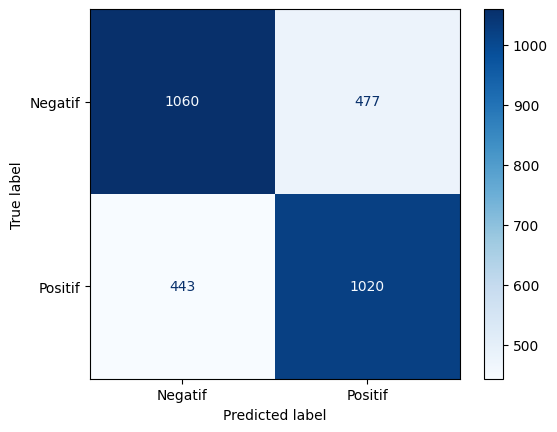


Rapport de classification :
               precision    recall  f1-score   support

           0       0.71      0.69      0.70      1537
           1       0.68      0.70      0.69      1463

    accuracy                           0.69      3000
   macro avg       0.69      0.69      0.69      3000
weighted avg       0.69      0.69      0.69      3000



In [34]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# Variable cible
y = data['Etiquette']

# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X_glove, y, test_size=0.3, random_state=42)

# Créer l'instance du modèle de régression logistique
model = LogisticRegression()
model.fit(X_train, y_train)

# Prédire les valeurs sur les données de test
y_pred = model.predict(X_test)

# Calculer la matrice de confusion
conf_matrix = confusion_matrix(y_test, y_pred)
conf_matrix_df = pd.DataFrame(conf_matrix, index=['Actual Negatif', 'Actual Positif'], columns=['Predicted Negatif', 'Predicted Positif'])
print("Matrice de confusion :\n", conf_matrix_df)

# Afficher la matrice de confusion sous forme de graphique
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Negatif', 'Positif'])
disp.plot(cmap=plt.cm.Blues)
plt.show()

# Afficher le rapport de classification
print("\nRapport de classification :\n", classification_report(y_test, y_pred))


In [35]:
# Convertir les étiquettes 4 en 1 dans y et y_test
y = y.replace(4, 1)
y_test = y_test.replace(4, 1)

In [36]:
from sklearn.model_selection import train_test_split
# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X_glove, y, test_size=0.3, random_state=42)


In [37]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Définir la grille de paramètres
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],  # Paramètre de régularisation
    'solver': ['liblinear', 'saga'],  # Méthodes de résolution
    'max_iter': [100, 200, 500]
}

# Appliquer GridSearchCV pour optimiser la régression logistique
grid = GridSearchCV(LogisticRegression(), param_grid, cv=5, scoring='f1')
grid.fit(X_train, y_train)

# Afficher les meilleurs paramètres trouvés
print("Meilleurs paramètres : ", grid.best_params_)


Meilleurs paramètres :  {'C': 1, 'max_iter': 100, 'solver': 'saga'}


Matrice de confusion :
                 Predicted Negatif  Predicted Positif
Actual Negatif               1062                475
Actual Positif                443               1020


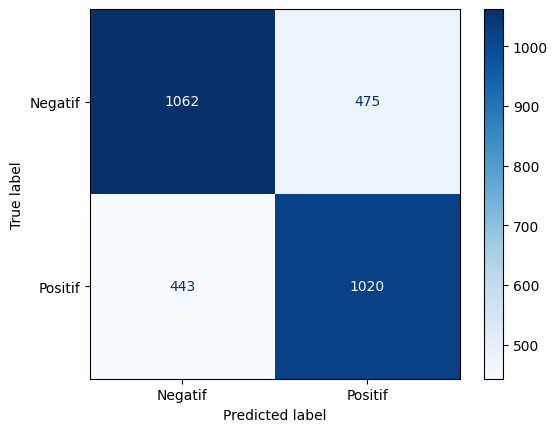


Rapport de classification :
               precision    recall  f1-score   support

           0       0.71      0.69      0.70      1537
           1       0.68      0.70      0.69      1463

    accuracy                           0.69      3000
   macro avg       0.69      0.69      0.69      3000
weighted avg       0.69      0.69      0.69      3000



In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# Prédire sur les données de test avec le meilleur modèle trouvé
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

# Calculer et afficher la matrice de confusion
conf_matrix = confusion_matrix(y_test, y_pred)
conf_matrix_df = pd.DataFrame(conf_matrix, index=['Actual Negatif', 'Actual Positif'], columns=['Predicted Negatif', 'Predicted Positif'])
print("Matrice de confusion :\n", conf_matrix_df)

# Afficher la matrice de confusion sous forme de graphique
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Negatif', 'Positif'])
disp.plot(cmap=plt.cm.Blues)
plt.show()

# Afficher le rapport de classification
print("\nRapport de classification :\n", classification_report(y_test, y_pred))


### <a name="C5">2 - Modèle LSTM(Long Short-Term Memory)</a>

In [40]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from transformers import DistilBertTokenizer

In [41]:
data.sample(20)

,Etiquette,Tweet_corrige,Tweet_corrige_tokenized
110399,0,aw know appreciate darling definitely distract...,"[aw, know, appreciate, darling, definitely, di..."
86241,0,wrote whole social study essay save,"[wrote, whole, social, study, essay, save]"
74062,0,going bed going come quite quickly,"[going, bed, going, come, quite, quickly]"
138200,1,thanks comment appreciate,"[thanks, comment, appreciate]"
133078,0,waiting concert miss la show girl,"[waiting, concert, miss, la, show, girl]"
100432,0,rain rain go away,"[rain, rain, go, away]"
70362,0,notice havent,"[notice, havent]"
58792,0,darn dish network feud still cant get wont get...,"[darn, dish, network, feud, still, cant, get, ..."
141862,0,tired cleaning room,"[tired, cleaning, room]"
78527,0,surgery next costuming pretty much hold,"[surgery, next, costuming, pretty, much, hold]"


In [42]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

# Préparer le vocabulaire et tokenisation simplifiée
def simple_tokenizer(text, vocab):
    return [vocab.get(word, vocab["[UNK]"]) for word in text.lower().split()]

# Construire un vocabulaire simple à partir des tweets
vocab = {"[PAD]": 0, "[UNK]": 1}
for tweet in data['Tweet_corrige']:
    for word in tweet.lower().split():
        if word not in vocab:
            vocab[word] = len(vocab)

# Transformer les phrases en tokens pré-traités
class TextDataset(Dataset):
    def __init__(self, dataframe, vocab):
        self.data = dataframe
        self.vocab = vocab
        self.inputs = [
            simple_tokenizer(text, self.vocab)[:20] + [0] * (20 - len(text.split())) for text in dataframe['Tweet_corrige']
        ]
        self.labels = torch.tensor(dataframe['Etiquette'].values)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return torch.tensor(self.inputs[idx]), self.labels[idx]

# Créer le DataLoader
dataset = TextDataset(data, vocab)
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

# Définir le modèle LSTM pour la classification de texte
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, output_size):
        super(LSTMClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(embed_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        with torch.no_grad():  # Désactiver le gradient sur l'embedding
            embedded = self.embedding(x)
        lstm_out, _ = self.lstm(embedded)
        # Prendre la dernière sortie de LSTM
        final_feature_map = lstm_out[:, -1, :]
        out = self.fc(final_feature_map)
        return out

# Initialiser le modèle, la fonction de perte et l'optimiseur
vocab_size = len(vocab)
embed_size = 32  # Réduit pour alléger le modèle
hidden_size = 32  # Réduit pour alléger le modèle
output_size = 2

model = LSTMClassifier(vocab_size, embed_size, hidden_size, output_size)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Entraîner le modèle
num_epochs = 3  # Réduit pour des tests plus rapides
for epoch in range(num_epochs):
    for inputs, labels in dataloader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item()}")

# Exemple d'inférence
with torch.no_grad():
    text = "I enjoyed this movie"
    inputs = torch.tensor([simple_tokenizer(text, vocab)[:20] + [0] * (20 - len(text.split()))])
    output = model(inputs)
    predicted_class = torch.argmax(output, dim=1).item()
    print(f"Predicted class for '{text}': {predicted_class}")

Epoch 1/3, Loss: 0.695823073387146
Epoch 2/3, Loss: 0.6933637857437134
Epoch 3/3, Loss: 0.6880665421485901
Predicted class for 'I enjoyed this movie': 1


##### Optimiser les hypers paramètres

In [44]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

# Préparer le vocabulaire et tokenisation simplifiée
def simple_tokenizer(text, vocab):
    return [vocab.get(word, vocab["[UNK]"]) for word in text.lower().split()]

# Construire un vocabulaire simple à partir des tweets
vocab = {"[PAD]": 0, "[UNK]": 1}
for tweet in data['Tweet_corrige']:
    for word in tweet.lower().split():
        if word not in vocab:
            vocab[word] = len(vocab)

# Transformer les phrases en tokens pré-traités
class TextDataset(Dataset):
    def __init__(self, dataframe, vocab):
        self.data = dataframe
        self.vocab = vocab
        self.inputs = [
            simple_tokenizer(text, self.vocab)[:20] + [0] * (20 - len(text.split())) for text in dataframe['Tweet_corrige']
        ]
        self.labels = torch.tensor(dataframe['Etiquette'].values)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return torch.tensor(self.inputs[idx]), self.labels[idx]

# Créer le DataLoader
dataset = TextDataset(data, vocab)
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

# Définir le modèle LSTM pour la classification de texte
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, output_size):
        super(LSTMClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(embed_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        with torch.no_grad():  # Désactiver le gradient sur l'embedding
            embedded = self.embedding(x)
        lstm_out, _ = self.lstm(embedded)
        # Prendre la dernière sortie de LSTM
        final_feature_map = lstm_out[:, -1, :]
        out = self.fc(final_feature_map)
        return out

# Initialiser le modèle, la fonction de perte et l'optimiseur
vocab_size = len(vocab)
embed_size = 64  
hidden_size = 64  
output_size = 2
learning_rate = 0.0005

model = LSTMClassifier(vocab_size, embed_size, hidden_size, output_size)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Entraîner le modèle
num_epochs = 10  # 
for epoch in range(num_epochs):
    for inputs, labels in dataloader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item()}")

# Exemple d'inférence
with torch.no_grad():
    text = "I enjoyed this movie"
    inputs = torch.tensor([simple_tokenizer(text, vocab)[:20] + [0] * (20 - len(text.split()))])
    output = model(inputs)
    predicted_class = torch.argmax(output, dim=1).item()
    print(f"Predicted class for '{text}': {predicted_class}")

Epoch 1/10, Loss: 0.6793233752250671
Epoch 2/10, Loss: 0.6938226222991943
Epoch 3/10, Loss: 0.694709062576294
Epoch 4/10, Loss: 0.6933994293212891
Epoch 5/10, Loss: 0.693242073059082
Epoch 6/10, Loss: 0.6933577656745911
Epoch 7/10, Loss: 0.7000437378883362
Epoch 8/10, Loss: 0.7513163685798645
Epoch 9/10, Loss: 0.7040472030639648
Epoch 10/10, Loss: 0.3644457161426544
Predicted class for 'I enjoyed this movie': 0


##### Exemples de Prédictions

### <a name="C6">    2.1 - Évaluation du Modèle</a>

Rapport de classification :
               precision    recall  f1-score   support

    Classe 0       0.69      0.83      0.75      5000
    Classe 1       0.79      0.62      0.69      5000

    accuracy                           0.73     10000
   macro avg       0.74      0.73      0.72     10000
weighted avg       0.74      0.73      0.72     10000



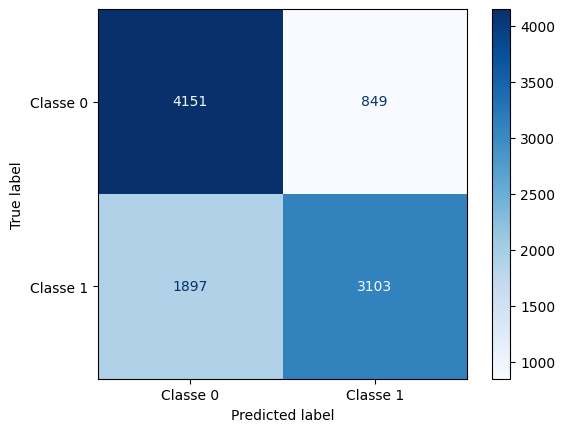

In [47]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import torch

# Mettre le modèle en mode évaluation
model.eval()

# Initialiser les listes pour stocker les prédictions et les labels réels
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in dataloader:
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1)
        
        # Stocker les prédictions et les labels réels
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Générer le rapport de classification
print("Rapport de classification :\n", classification_report(all_labels, all_preds, target_names=['Classe 0', 'Classe 1']))

# Calculer la matrice de confusion
conf_matrix = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Classe 0', 'Classe 1'])
disp.plot(cmap="Blues")
plt.show()


### <a name="C7">   2.2 - FastText</a>

In [49]:
from gensim.models import FastText

# Charger les tweets et les tokeniser
with open("tweets.txt", "r", encoding="utf-8") as f:
    sentences = [line.strip().split() for line in f]

# Entraîner le modèle FastText
fasttext_model = FastText(sentences, vector_size=64, window=5, min_count=1, sg=1)

# Vérifier la dimension des vecteurs
embed_size = fasttext_model.vector_size

In [50]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

# Construire le vocabulaire et la matrice d'embeddings à partir du modèle FastText
vocab = {"[PAD]": 0, "[UNK]": 1}
embedding_matrix = [np.zeros(embed_size), np.mean(fasttext_model.wv.vectors, axis=0)]

for word in fasttext_model.wv.index_to_key:
    vocab[word] = len(vocab)
    embedding_matrix.append(fasttext_model.wv[word])

embedding_matrix = np.array(embedding_matrix)
embedding_matrix = torch.tensor(embedding_matrix, dtype=torch.float)


In [51]:
# Tokenizer simple pour transformer les tweets en indices
def simple_tokenizer(text, vocab):
    return [vocab.get(word, vocab["[UNK]"]) for word in text.lower().split()]

# Définir le Dataset pour charger les données
class TextDataset(Dataset):
    def __init__(self, dataframe, vocab):
        self.data = dataframe
        self.vocab = vocab
        self.inputs = [
            simple_tokenizer(text, self.vocab)[:20] + [0] * (20 - len(text.split())) 
            for text in dataframe['Tweet_corrige']
        ]
        self.labels = torch.tensor(dataframe['Etiquette'].values)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return torch.tensor(self.inputs[idx]), self.labels[idx]

# Créer le DataLoader
dataset = TextDataset(data, vocab)
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)


###### Définir le Modèle LSTM avec Embeddings FastText

In [53]:
class LSTMClassifier(nn.Module):
    def __init__(self, embedding_matrix, hidden_size, output_size):
        super(LSTMClassifier, self).__init__()
        num_embeddings, embed_size = embedding_matrix.shape
        self.embedding = nn.Embedding(num_embeddings, embed_size)
        self.embedding.weight = nn.Parameter(embedding_matrix)  # Initialiser avec FastText
        self.embedding.weight.requires_grad = False  # Geler les embeddings
        self.lstm = nn.LSTM(embed_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, _ = self.lstm(embedded)
        final_feature_map = lstm_out[:, -1, :]
        out = self.fc(final_feature_map)
        return out


In [54]:
# Initialiser les paramètres du modèle
embed_size = 64  
hidden_size = 64  
output_size = 2
learning_rate = 0.0005

# Initialiser le modèle, la fonction de perte et l'optimiseur
model = LSTMClassifier(embedding_matrix, hidden_size, output_size)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate)

# Entraîner le modèle
num_epochs = 10
for epoch in range(num_epochs):
    for inputs, labels in dataloader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item()}")

Epoch 1/10, Loss: 0.6938332319259644
Epoch 2/10, Loss: 0.6554248332977295
Epoch 3/10, Loss: 0.6263023614883423
Epoch 4/10, Loss: 0.7375024557113647
Epoch 5/10, Loss: 0.74392169713974
Epoch 6/10, Loss: 0.6947259306907654
Epoch 7/10, Loss: 0.6329796314239502
Epoch 8/10, Loss: 0.6779046058654785
Epoch 9/10, Loss: 0.7865116000175476
Epoch 10/10, Loss: 0.7003939747810364


Rapport de classification :
               precision    recall  f1-score   support

    Classe 0       0.62      0.19      0.29      5000
    Classe 1       0.52      0.89      0.66      5000

    accuracy                           0.54     10000
   macro avg       0.57      0.54      0.47     10000
weighted avg       0.57      0.54      0.47     10000



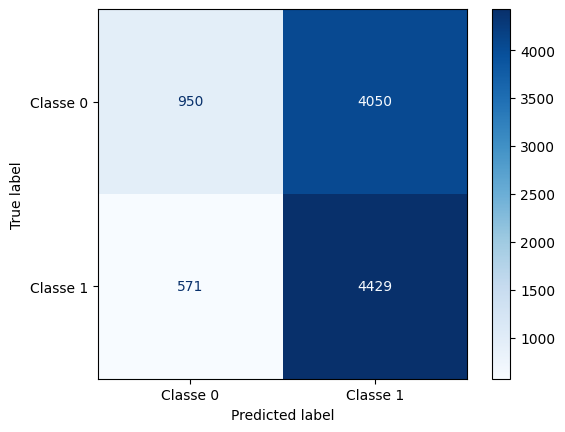

In [55]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Mettre le modèle en mode évaluation
model.eval()

# Stocker toutes les prédictions et les labels réels
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in dataloader:
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Afficher le rapport de classification
print("Rapport de classification :\n", classification_report(all_labels, all_preds, target_names=['Classe 0', 'Classe 1']))

# Afficher la matrice de confusion
conf_matrix = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Classe 0', 'Classe 1'])
disp.plot(cmap="Blues")
plt.show()


### <a name="C8">    2.3 - GloVe</a>

In [57]:
# Charger les vecteurs GloVe dans un dictionnaire
embedding_dict = {}
embed_size = 100  # Ajustez à la dimension choisie de GloVe (par exemple, 100 pour glove.6B.100d)

with open("/Users/aesseddiki/glove.6B.100d.txt", "r", encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        embedding_dict[word] = vector


##### Créez un vocabulaire et une matrice d'embeddings en utilisant les vecteurs GloVe pour 'Tweet_corrige'

In [59]:
import numpy as np
import torch

# Construire le vocabulaire et la matrice d'embeddings à partir des vecteurs GloVe
vocab = {"[PAD]": 0, "[UNK]": 1}
embedding_matrix = [np.zeros(embed_size), np.random.normal(size=(embed_size,))]

for tweet in data['Tweet_corrige']:
    for word in tweet.lower().split():
        if word not in vocab:
            vocab[word] = len(vocab)
            if word in embedding_dict:
                embedding_matrix.append(embedding_dict[word])
            else:
                embedding_matrix.append(np.random.normal(size=(embed_size,)))

embedding_matrix = np.array(embedding_matrix)
embedding_matrix = torch.tensor(embedding_matrix, dtype=torch.float)

In [60]:
from torch.utils.data import Dataset, DataLoader

# Tokenizer simple pour transformer les tweets en indices
def simple_tokenizer(text, vocab):
    return [vocab.get(word, vocab["[UNK]"]) for word in text.lower().split()]

# Dataset pour charger les données
class TextDataset(Dataset):
    def __init__(self, dataframe, vocab):
        self.data = dataframe
        self.vocab = vocab
        self.inputs = [
            simple_tokenizer(text, self.vocab)[:20] + [0] * (20 - len(text.split())) 
            for text in dataframe['Tweet_corrige']
        ]
        self.labels = torch.tensor(dataframe['Etiquette'].values)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return torch.tensor(self.inputs[idx]), self.labels[idx]

# Créer le DataLoader
dataset = TextDataset(data, vocab)
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)


##### Définir le Modèle LSTM avec Embeddings GloVe

In [62]:
import torch.nn as nn

class LSTMClassifier(nn.Module):
    def __init__(self, embedding_matrix, hidden_size, output_size):
        super(LSTMClassifier, self).__init__()
        num_embeddings, embed_size = embedding_matrix.shape
        self.embedding = nn.Embedding(num_embeddings, embed_size)
        self.embedding.weight = nn.Parameter(embedding_matrix)  # Initialiser avec GloVe
        self.embedding.weight.requires_grad = False  # Geler les embeddings
        self.lstm = nn.LSTM(embed_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, _ = self.lstm(embedded)
        final_feature_map = lstm_out[:, -1, :]
        out = self.fc(final_feature_map)
        return out

In [63]:
import torch.optim as optim

# Initialiser les paramètres du modèle
embed_size = 64  
hidden_size = 64  
output_size = 2
learning_rate = 0.0005

# Initialiser le modèle, la fonction de perte et l'optimiseur
model = LSTMClassifier(embedding_matrix, hidden_size, output_size)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate)

# Entraîner le modèle
num_epochs = 10
for epoch in range(num_epochs):
    for inputs, labels in dataloader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item()}")


Epoch 1/10, Loss: 0.5505355596542358
Epoch 2/10, Loss: 0.7156457304954529
Epoch 3/10, Loss: 0.6099777817726135
Epoch 4/10, Loss: 0.8016471862792969
Epoch 5/10, Loss: 0.5161105394363403
Epoch 6/10, Loss: 0.46582740545272827
Epoch 7/10, Loss: 0.5583043694496155
Epoch 8/10, Loss: 0.6918651461601257
Epoch 9/10, Loss: 0.7945472002029419
Epoch 10/10, Loss: 0.5358098745346069


Rapport de classification :
               precision    recall  f1-score   support

    Classe 0       0.87      0.76      0.81      5000
    Classe 1       0.79      0.88      0.83      5000

    accuracy                           0.82     10000
   macro avg       0.83      0.82      0.82     10000
weighted avg       0.83      0.82      0.82     10000



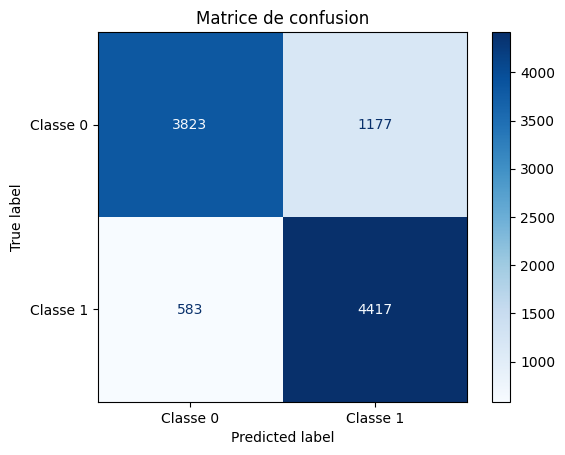

In [64]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import torch

# Mettre le modèle en mode évaluation
model.eval()

# Initialiser les listes pour stocker les prédictions et les labels réels
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in dataloader:
        # Envoyer les inputs et labels sur le même appareil que le modèle (CPU ou GPU)
        inputs, labels = inputs.to(model.embedding.weight.device), labels.to(model.embedding.weight.device)
        
        # Faire des prédictions
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1)
        
        # Stocker les prédictions et les labels réels
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Afficher le rapport de classification
print("Rapport de classification :\n", classification_report(all_labels, all_preds, target_names=['Classe 0', 'Classe 1']))

# Calculer et afficher la matrice de confusion
conf_matrix = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Classe 0', 'Classe 1'])
disp.plot(cmap="Blues")
plt.title("Matrice de confusion")
plt.show()

### <a name="C9">3 - Modèle BERT</a>

#### BERT

#### Créer un modèle BERT pour la classification

In [86]:
from transformers import BertTokenizer, BertForSequenceClassification
import torch

# Charger le tokenizer de BERT
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Charger le modèle BERT pour la classification avec 2 labels (par exemple, pour une tâche binaire)
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

# Déterminer si un GPU est disponible et déplacer le modèle sur le bon appareil
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [88]:
# Supprimer les valeurs manquantes dans les colonnes nécessaires
data = data.dropna(subset=['Tweet_corrige', 'Etiquette'])

# Convertir les labels en entiers si ce n'est pas déjà fait
data['Etiquette'] = data['Etiquette'].astype(int)

# Tokeniser les tweets
encoded_data = tokenizer(
    data['Tweet_corrige'].tolist(),  # Texte à tokeniser
    padding=True,
    truncation=True,
    max_length=64,  # Longueur maximale des séquences
    return_tensors='pt'  # Format PyTorch
)

# Récupérer les inputs pour BERT
input_ids = encoded_data['input_ids']
attention_masks = encoded_data['attention_mask']

# Convertir les labels en tensor PyTorch
labels = torch.tensor(data['Etiquette'].tolist())


In [90]:
from torch.utils.data import DataLoader, TensorDataset, RandomSampler

# Créer un dataset PyTorch
train_dataset = TensorDataset(input_ids, attention_masks, labels)

# Initialiser le DataLoader pour l’entraînement avec des mini-lots
train_dataloader = DataLoader(train_dataset, sampler=RandomSampler(train_dataset), batch_size=16)  # Ajustez batch_size selon vos besoins


In [92]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

# Initialiser l'optimiseur AdamW
optimizer = AdamW(model.parameters(), lr=2e-5)  # Ajustez le taux d'apprentissage si nécessaire

# Scheduler pour diminuer progressivement le taux d'apprentissage
epochs = 3
total_steps = len(train_dataloader) * epochs

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,  # Commence le décrochage après 0 étapes
    num_training_steps=total_steps
)


In [ ]:
from tqdm import tqdm

# Passer le modèle en mode entraînement
model.train()

for epoch in range(epochs):
    print(f"Epoch {epoch + 1}/{epochs}")
    total_loss = 0

    for batch in tqdm(train_dataloader, desc="Training"):
        # Récupérer les données du batch et les envoyer au bon appareil
        batch_input_ids, batch_attention_masks, batch_labels = [b.to(device) for b in batch]

        # Remettre les gradients à zéro
        optimizer.zero_grad()

        # Passer les données dans le modèle
        outputs = model(
            input_ids=batch_input_ids,
            attention_mask=batch_attention_masks,
            labels=batch_labels
        )

        # Calculer la perte et faire la rétropropagation
        loss = outputs.loss
        total_loss += loss.item()
        loss.backward()

        # Mettre à jour les poids
        optimizer.step()
        scheduler.step()  # Mise à jour du taux d'apprentissage

    avg_loss = total_loss / len(train_dataloader)
    print(f"Average Loss for Epoch {epoch + 1}: {avg_loss}")


Epoch 1/3


Training:  42%|████▏     | 260/625 [09:50<13:37,  2.24s/it]

In [ ]:
# Sauvegarder le modèle fine-tuné
model.save_pretrained("path/to/save/fine_tuned_model")
tokenizer.save_pretrained("path/to/save/fine_tuned_model")


In [71]:
xxxx

NameError: name 'xxxx' is not defined

In [72]:
import os
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'

In [74]:
data.head()

,Etiquette,Tweet_corrige,Tweet_corrige_tokenized
44353,0,huh who going showcase sure come anyways trip ...,"[huh, who, going, showcase, sure, come, anyway..."
60769,0,grandpa hospital day suck get better,"[grandpa, hospital, day, suck, get, better]"
92787,0,know kept saying hour going corner sit traffic...,"[know, kept, saying, hour, going, corner, sit,..."
119851,0,sophomore g wan na go c f,"[sophomore, g, wan, na, go, c, f]"
86450,0,sad coz sad,"[sad, coz, sad]"


In [76]:
from transformers import BertTokenizer, BertForSequenceClassification
import torch

# Charger le tokenizer de BERT
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Charger le modèle BERT pour la classification avec 2 labels (par exemple, pour une tâche binaire)
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [78]:
# Convertir les labels en entiers si ce n'est pas déjà fait
data['Etiquette'] = data['Etiquette'].astype(int)

# Tokeniser les tweets
encoded_data = tokenizer(
    data['Tweet_corrige'].tolist(),  # Texte à tokeniser
    padding=True,
    truncation=True,
    max_length=64,  # Longueur maximale des séquences
    return_tensors='pt'  # Format PyTorch
)

# Récupérer les inputs pour BERT
input_ids = encoded_data['input_ids']
attention_masks = encoded_data['attention_mask']

# Convertir les labels en tensor PyTorch
labels = torch.tensor(data['Etiquette'].tolist())


In [80]:
from torch.utils.data import DataLoader, TensorDataset

# Créer un dataset PyTorch
dataset = TensorDataset(input_ids, attention_masks, labels)

# Initialiser le DataLoader pour l’entraînement avec des mini-lots
train_dataloader = DataLoader(dataset, batch_size=16, shuffle=True)  # Ajustez batch_size selon vos besoins


In [82]:
import torch.optim as optim

# Initialiser l'optimiseur
optimizer = optim.AdamW(model.parameters(), lr=1e-5)

In [84]:
from tqdm import tqdm

# Déterminer si un GPU est disponible et déplacer le modèle
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Passer le modèle en mode entraînement
model.train()

# Nombre d’époques
epochs = 3  # Ajustez selon vos besoins

for epoch in range(epochs):
    total_loss = 0

    for batch in tqdm(train_dataloader, desc=f"Epoch {epoch + 1}"):
        batch_input_ids, batch_attention_masks, batch_labels = batch

        # Envoyer les données sur le même appareil que le modèle (GPU ou CPU)
        batch_input_ids = batch_input_ids.to(device)
        batch_attention_masks = batch_attention_masks.to(device)
        batch_labels = batch_labels.to(device)

        # Remettre les gradients à zéro
        optimizer.zero_grad()

        # Passer les données dans le modèle
        outputs = model(
            input_ids=batch_input_ids,
            attention_mask=batch_attention_masks,
            labels=batch_labels
        )

        # Calculer la perte
        loss = outputs.loss
        total_loss += loss.item()

        # Rétropropagation
        loss.backward()

        # Mettre à jour les poids
        optimizer.step()

    # Afficher la perte moyenne pour l'époque
    avg_loss = total_loss / len(train_dataloader)
    print(f"Average Loss for Epoch {epoch + 1}: {avg_loss}")


Epoch 1: 100%|██████████| 625/625 [23:48<00:00,  2.29s/it]


Average Loss for Epoch 1: 0.5880579959869385


Epoch 2:   8%|▊         | 53/625 [02:09<23:17,  2.44s/it]


KeyboardInterrupt: 

In [ ]:
print(data.head())          # Afficher les premières lignes du DataFrame
print(data.columns)         # Vérifier les noms des colonnes


In [ ]:
from transformers import BertTokenizer, BertForSequenceClassification

# Charger le tokenizer de BERT
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Charger le modèle BERT pour la classification avec 2 labels (par exemple pour une tâche binaire)
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

In [ ]:
# Tokeniser les tweets
encoded_data = tokenizer(
    data['Tweet_corrige'].tolist(),  # Texte à tokeniser
    padding=True,
    truncation=True,
    max_length=64,  # Longueur maximale des séquences
    return_tensors='pt'  # Format PyTorch
)

# Récupérer les inputs pour BERT
input_ids = encoded_data['input_ids']
attention_masks = encoded_data['attention_mask']

# Assurez-vous que vos labels sont bien dans un format tensor (PyTorch)
labels = torch.tensor(data['label'].tolist())  # Adapter à votre dataset


#### ensembles d'entraînement et de validation

#### DistilBERT BERT allégé 

In [ ]:
import torch
torch.cuda.empty_cache()

In [ ]:
import os
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'

In [ ]:
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

# Charger le tokenizer et le modèle de classification DistilBERT
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)


In [ ]:
import torch

# Exemple de données de texte à tokeniser
texts = data['Tweet_corrige'].tolist()  # Assurez-vous que `data` est bien défini
labels = torch.tensor(data['Etiquette'].replace(4, 1).values)  # Convertir les étiquettes en 0 et 1

# Tokeniser les textes
encoded_data = tokenizer(
    texts,
    padding=True,
    truncation=True,
    max_length=64,  # Limiter la longueur pour économiser de la mémoire
    return_tensors='pt'
)

# Extraire les input_ids et attention_masks
input_ids = encoded_data['input_ids']
attention_masks = encoded_data['attention_mask']


In [ ]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset, RandomSampler, SequentialSampler

# Diviser les données
train_inputs, val_inputs, train_labels, val_labels = train_test_split(input_ids, labels, test_size=0.1, random_state=42)
train_masks, val_masks, _, _ = train_test_split(attention_masks, labels, test_size=0.1, random_state=42)

# Créer les DataLoaders pour itérer sur les données
batch_size = 4  # une taille de lot plus petite pour réduire la mémoire

# Créer les datasets et DataLoader
train_data = TensorDataset(train_inputs, train_masks, train_labels)
train_sampler = RandomSampler(train_data)
train_dataloader = DataLoader(train_data, sampler=train_sampler, batch_size=batch_size)

val_data = TensorDataset(val_inputs, val_masks, val_labels)
val_sampler = SequentialSampler(val_data)
val_dataloader = DataLoader(val_data, sampler=val_sampler, batch_size=batch_size)


In [ ]:
from transformers import AdamW, get_linear_schedule_with_warmup

# Configurer l'optimiseur
optimizer = AdamW(model.parameters(), lr=2e-5, eps=1e-8)

# Nombre d'époques
epochs = 3

# Planificateur de taux d'apprentissage
total_steps = len(train_dataloader) * epochs
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

# Mettre le modèle en mode entraînement
model.train()

for epoch in range(epochs):
    print(f'--- Époque {epoch + 1}/{epochs} ---')
    total_train_loss = 0

    # Boucle de batchs pour l’entraînement
    for batch in train_dataloader:
        # Charger les données du batch
        b_input_ids, b_input_mask, b_labels = batch
        
        # Réinitialiser les gradients
        model.zero_grad()
        
        # Exécuter la passe avant (forward pass)
        outputs = model(input_ids=b_input_ids, attention_mask=b_input_mask, labels=b_labels)
        loss = outputs.loss
        logits = outputs.logits

        total_train_loss += loss.item()
        
        # Calculer les gradients et les mettre à jour
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

    # Afficher la perte moyenne pour l'époque
    avg_train_loss = total_train_loss / len(train_dataloader)
    print(f'  Loss d\'entraînement moyen : {avg_train_loss:.2f}')


Realiser le modele LSTM

In [ ]:
git

In [ ]:
Recherche d'application Mlops